# Base 02 — Pilgrim's Pride (PPC) com variáveis exógenas

Pipeline completo para prever o preço de abertura (`Open`) do próximo pregão: auditoria, EDA, limpeza, estacionariedade, STL, features sem vazamento, tuning temporal, walk-forward, MAE, resíduos, Ljung–Box, importância e persistência.

O desenho segue a estrutura da `base_05`, adaptada à base correta `data/PPC_exogenous.csv`. O grupo mantém a especialização em **Elastic Net**, mas compara os quatro modelos exigidos: SARIMAX, Holt-Winters, Random Forest e Elastic Net.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
from itertools import product
import hashlib
import json
import pickle
import sys
import time
import warnings

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow
import seaborn as sns
import sklearn
import statsmodels
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
BASE_ID = "base_02"
RANDOM_STATE = 42
DATA_DIR = PROJECT_ROOT / "data" / BASE_ID
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / BASE_ID
RAW_FILE = PROJECT_ROOT / "data" / "PPC_exogenous.csv"

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_STATE)

assert RAW_FILE.exists(), f"Arquivo raw ausente: {RAW_FILE}"
raw_hash_before = hashlib.sha256(RAW_FILE.read_bytes()).hexdigest()
print({
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn.__version__,
    "statsmodels": statsmodels.__version__,
    "matplotlib": matplotlib.__version__,
    "pyarrow": pyarrow.__version__,
    "raw_sha256": raw_hash_before,
})


{'python': '3.12.10', 'numpy': '2.5.3', 'pandas': '3.0.6', 'sklearn': '1.9.1', 'statsmodels': '0.15.0', 'matplotlib': '3.11.2', 'pyarrow': '25.0.1', 'raw_sha256': 'b008a6dd13cd9e1da955710745e92da7c1c19eb9a6d6f7d9d97de972c571629b'}


## A–C. Documentação, EDA e limpeza

A base contém preços ajustados da Pilgrim's Pride Corporation (`PPC`) e quatro sinais externos, de 25/07/2013 a 16/09/2026. O alvo é `Open`, em USD, um pregão à frente.

Contrato temporal:

- `Open`, `High`, `Low`, `Close` e `Volume`: observados até a origem; entram apenas por lags;
- `TSN_Close`, `XLP_Close`, `CALM_Close` e `USD_MXN`: `lag_only`, pois o valor do pregão previsto não é conhecido na origem;
- calendário da data prevista: `known_ahead`;
- horizonte: 1 pregão; passo entre origens: 1 pregão observado;
- o CSV original é somente leitura e sua integridade é verificada por SHA-256.


,value
rows,3430
start,2013-07-25 00:00:00
end,2026-09-16 00:00:00
missing_total,0
duplicate_dates,0
weekend_rows,0
nonpositive_prices,0
negative_volume,0
zero_volume_rows,124
ohlc_violations,0


,count
Date,
1.0,2743
3.0,686


Retornos fora de 3×IQR: 25; preservados como movimentos de mercado.


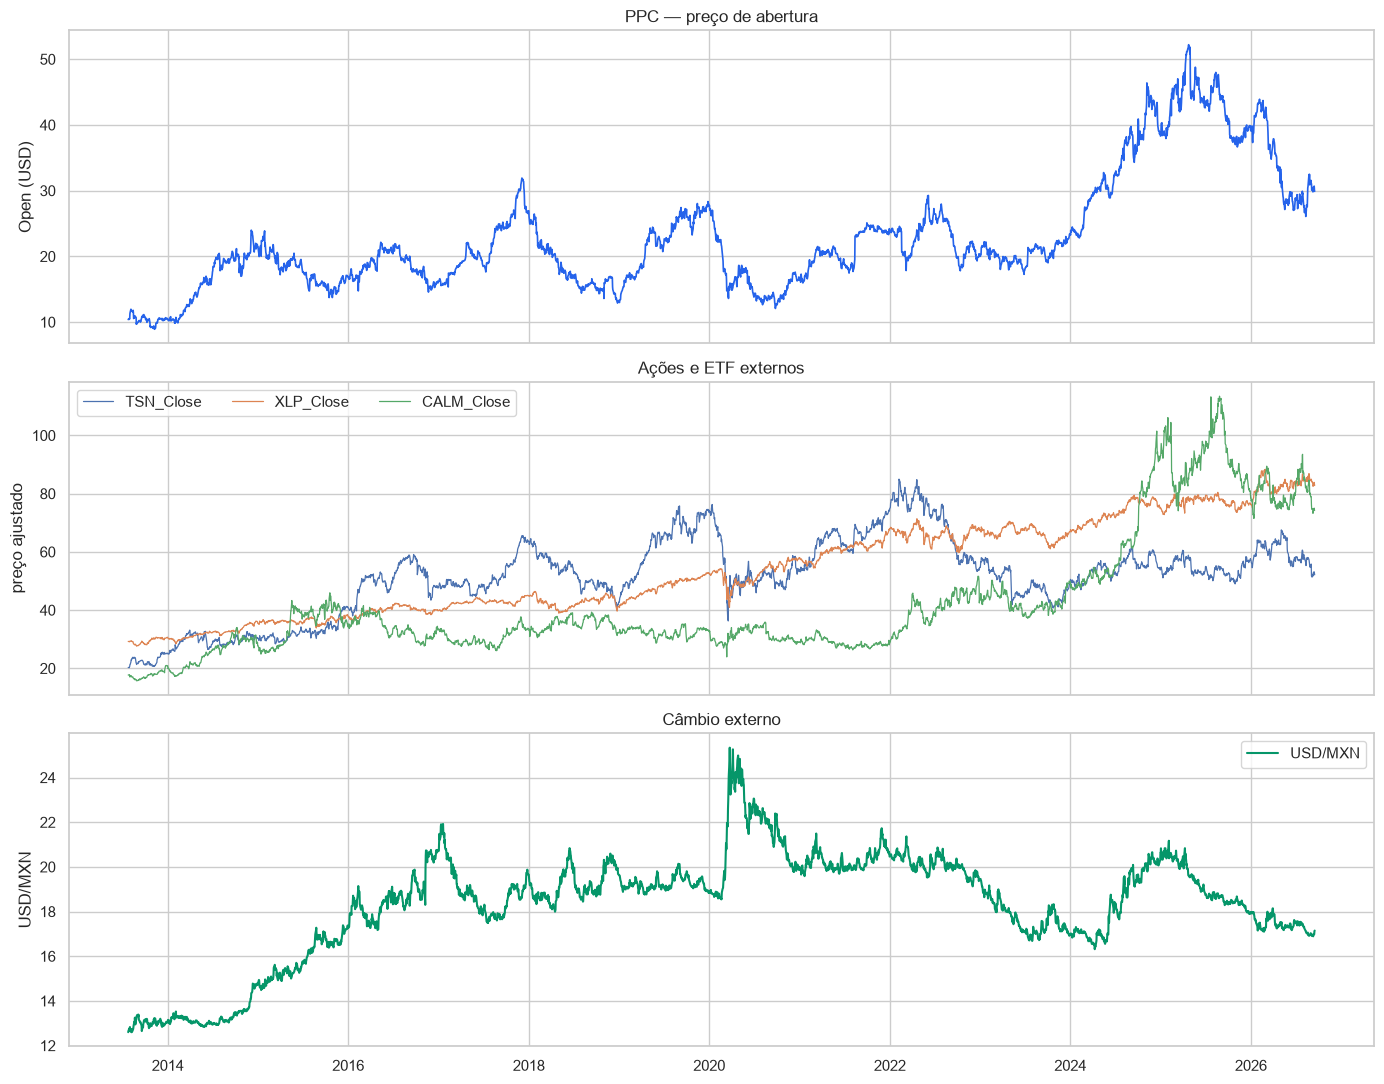

Base limpa salva sem imputação nem remoção: (3430, 10)


In [2]:
raw = pd.read_csv(RAW_FILE)
expected_columns = [
    "Date", "Open", "High", "Low", "Close", "Volume",
    "TSN_Close", "XLP_Close", "CALM_Close", "USD_MXN",
]
assert raw.columns.tolist() == expected_columns

df = raw.copy()
df["Date"] = pd.to_datetime(df["Date"], errors="raise").dt.normalize()
df = df.sort_values("Date").reset_index(drop=True)
price_cols = ["Open", "High", "Low", "Close", "TSN_Close", "XLP_Close", "CALM_Close", "USD_MXN"]

integrity = {
    "rows": len(df),
    "start": df["Date"].min(),
    "end": df["Date"].max(),
    "missing_total": int(df.isna().sum().sum()),
    "duplicate_dates": int(df["Date"].duplicated().sum()),
    "weekend_rows": int((df["Date"].dt.dayofweek >= 5).sum()),
    "nonpositive_prices": int((df[price_cols] <= 0).sum().sum()),
    "negative_volume": int((df["Volume"] < 0).sum()),
    "zero_volume_rows": int((df["Volume"] == 0).sum()),
    "ohlc_violations": int((
        (df["Low"] > df[["Open", "Close"]].min(axis=1))
        | (df["High"] < df[["Open", "Close"]].max(axis=1))
        | (df["Low"] > df["High"])
    ).sum()),
}
display(pd.Series(integrity, name="value").to_frame())
assert len(df) >= 1000
assert all(integrity[k] == 0 for k in [
    "missing_total", "duplicate_dates", "weekend_rows",
    "nonpositive_prices", "negative_volume", "ohlc_violations",
])

# Lacunas de calendário são esperadas em fins de semana e feriados; não há imputação de pregões.
gaps = df["Date"].diff().dt.days.dropna()
display(gaps.value_counts().sort_index().rename("count").to_frame())

returns = df["Open"].pct_change()
q1, q3 = returns.quantile([0.25, 0.75])
iqr = q3 - q1
outlier_mask = (returns < q1 - 3 * iqr) | (returns > q3 + 3 * iqr)
print(f"Retornos fora de 3×IQR: {int(outlier_mask.sum())}; preservados como movimentos de mercado.")

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
axes[0].plot(df["Date"], df["Open"], color="#2563eb", linewidth=1.2)
axes[0].set(title="PPC — preço de abertura", ylabel="Open (USD)")
for col in ["TSN_Close", "XLP_Close", "CALM_Close"]:
    axes[1].plot(df["Date"], df[col], label=col, linewidth=0.9)
axes[1].legend(ncol=3)
axes[1].set(title="Ações e ETF externos", ylabel="preço ajustado")
axes[2].plot(df["Date"], df["USD_MXN"], color="#059669", label="USD/MXN")
axes[2].set(title="Câmbio externo", ylabel="USD/MXN")
axes[2].legend()
plt.tight_layout()
plt.show()

cleaned = df.copy()
cleaned.to_csv(DATA_DIR / f"cleaned_{BASE_ID}.csv", index=False)
print("Base limpa salva sem imputação nem remoção:", cleaned.shape)


### Decisões de limpeza

| Etapa | Decisão | Justificativa |
|---|---|---|
| Datas | converter, normalizar, ordenar e exigir unicidade | preserva a ordem temporal |
| Pregões | manter somente as datas presentes | fins de semana e feriados não são observações ausentes |
| OHLC/exógenas | exigir valores positivos e consistência `Low ≤ Open/Close ≤ High` | bloqueia registros estruturalmente inválidos |
| Volume zero | manter e transformar com `log1p` quando usado | zero não produz infinito e pode ser um registro legítimo |
| Outliers de retorno | sinalizar por 3×IQR, sem remover | choques podem ser reais |
| Ausências/duplicatas | falhar | evita correções silenciosas e vazamento |


## D. Estacionariedade, STL e força da sazonalidade

O teste final é separado antes dos diagnósticos. ADF, ACF/PACF e escolha exploratória do período usam somente o desenvolvimento. São comparados `m ∈ {5, 10, 21, 63}`, representando semana, duas semanas, mês e trimestre aproximados de pregões.


{'development_end': Timestamp('2026-06-19 00:00:00'), 'test_start': Timestamp('2026-06-22 00:00:00'), 'test_observations': 63}


,series,adf_stat,p_value,lags,n,crit_5pct,stationary_5pct
0,Open (nível),-2.046107,2.667294e-01,28,3338,-2.862406,False
1,Open (1ª diferença),-10.398235,1.939806e-18,27,3338,-2.862406,True
2,Open (retorno),-40.559974,0.000000e+00,1,3364,-2.862400,True


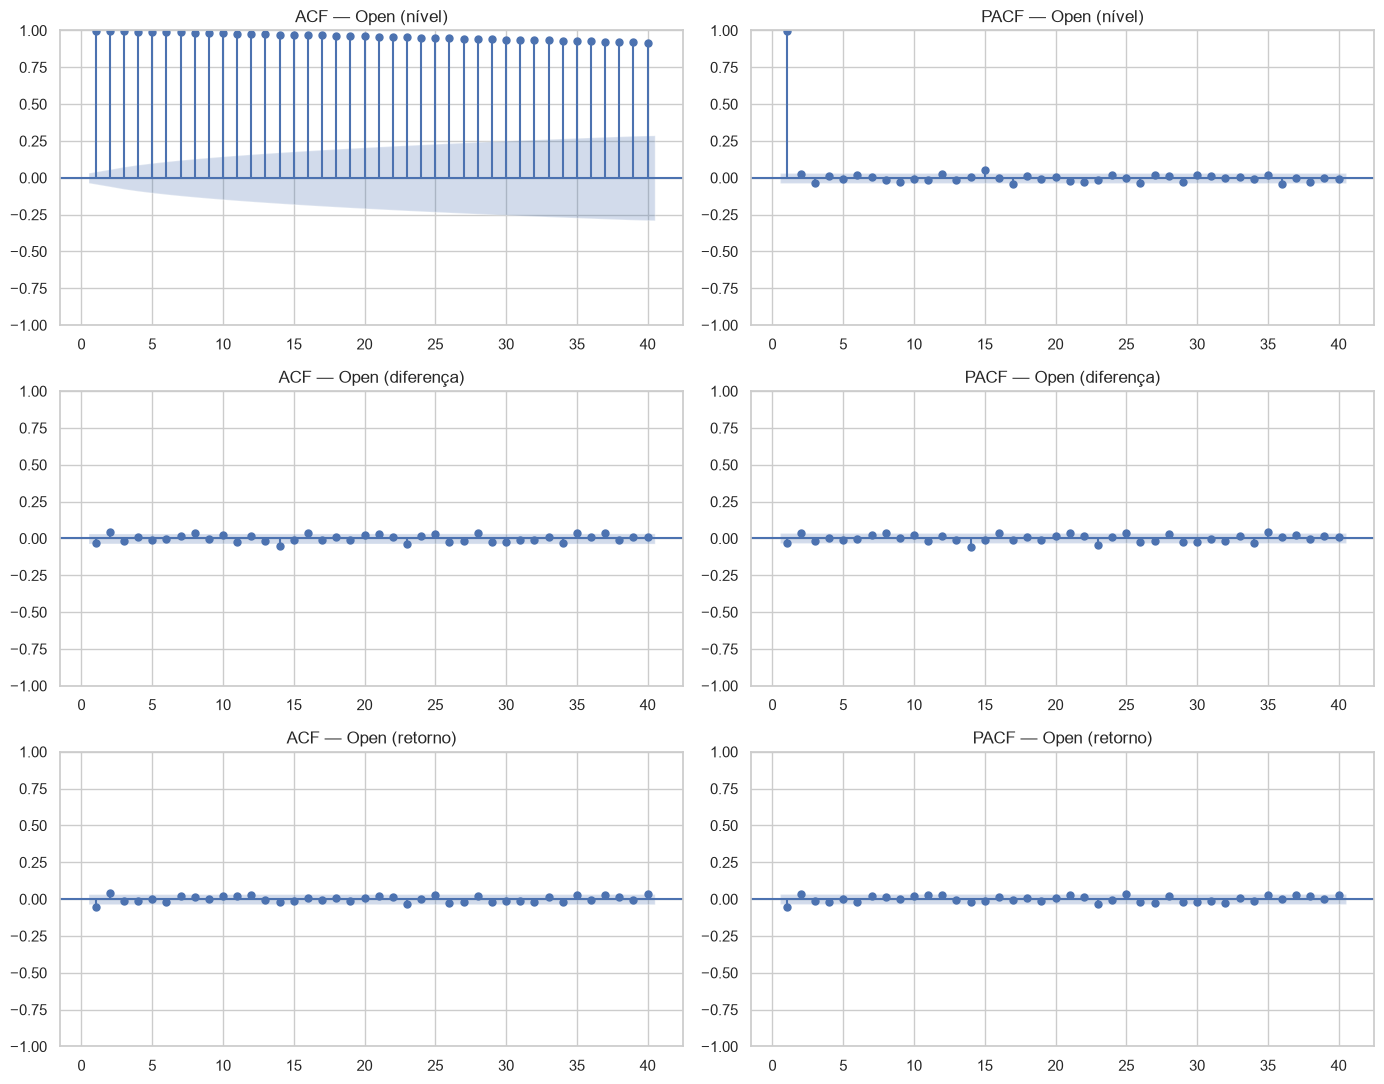

,m,seasonality_strength
3,63,0.032762
2,21,0.003903
1,10,0.000000
0,5,0.000000


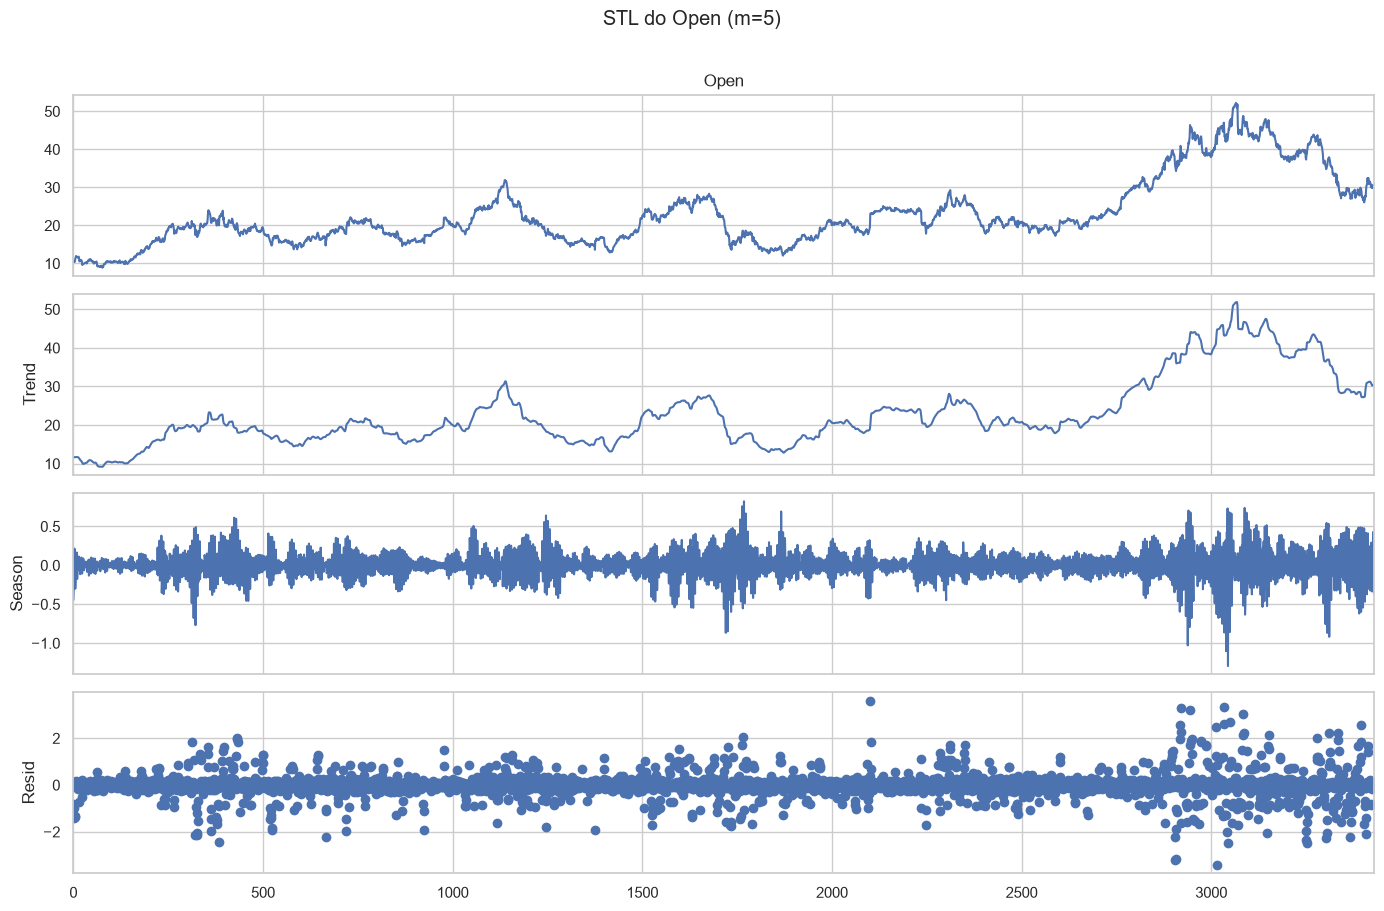

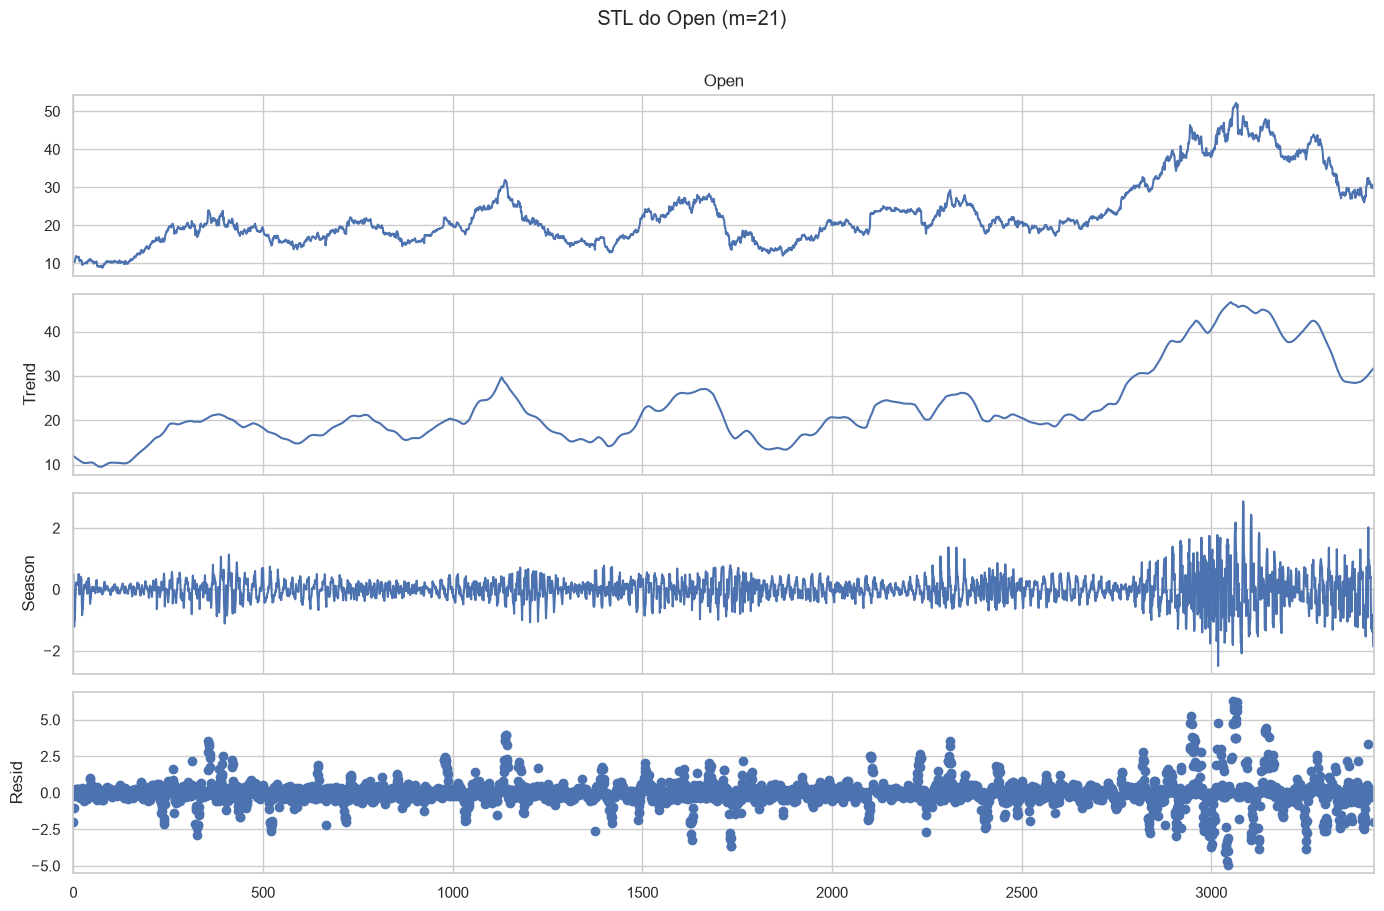

In [3]:
HORIZON = 1
ORIGIN_STEP = 1
TRAIN_MIN_OBS = 252
TEST_OBS = 63
SEASONAL_PERIOD = 5
PERIOD_CANDIDATES = [5, 10, 21, 63]

test_start_idx = len(cleaned) - TEST_OBS
development_end = cleaned.loc[test_start_idx - 1, "Date"]
test_start = cleaned.loc[test_start_idx, "Date"]
print({"development_end": development_end, "test_start": test_start, "test_observations": TEST_OBS})

development_open = cleaned.loc[:test_start_idx - 1, "Open"].reset_index(drop=True)

def adf_summary(series, name):
    series = pd.Series(series).dropna()
    stat, pvalue, usedlag, nobs, crit, _ = adfuller(series, autolag="AIC")
    return {
        "series": name, "adf_stat": float(stat), "p_value": float(pvalue),
        "lags": int(usedlag), "n": int(nobs), "crit_5pct": float(crit["5%"]),
        "stationary_5pct": bool(pvalue < 0.05),
    }

level = development_open
diff1 = development_open.diff().dropna()
returns_dev = development_open.pct_change().dropna()
display(pd.DataFrame([
    adf_summary(level, "Open (nível)"),
    adf_summary(diff1, "Open (1ª diferença)"),
    adf_summary(returns_dev, "Open (retorno)"),
]))

acf_lags = 40
fig, axes = plt.subplots(3, 2, figsize=(14, 11))
for row, (series, title) in enumerate([(level, "nível"), (diff1, "diferença"), (returns_dev, "retorno")]):
    plot_acf(series, lags=acf_lags, ax=axes[row, 0], zero=False)
    plot_pacf(series, lags=acf_lags, ax=axes[row, 1], zero=False, method="ywm")
    axes[row, 0].set_title(f"ACF — Open ({title})")
    axes[row, 1].set_title(f"PACF — Open ({title})")
plt.tight_layout()
plt.show()

seasonality_rows = []
for period in PERIOD_CANDIDATES:
    fitted = STL(development_open, period=period, robust=True).fit()
    strength = max(0.0, 1.0 - np.var(fitted.resid, ddof=1) / np.var(fitted.seasonal + fitted.resid, ddof=1))
    seasonality_rows.append({"m": period, "seasonality_strength": strength})
seasonality_table = pd.DataFrame(seasonality_rows).sort_values("seasonality_strength", ascending=False)
display(seasonality_table)

for period in [5, 21]:
    fig = STL(cleaned["Open"], period=period, robust=True).fit().plot()
    fig.set_size_inches(14, 9)
    plt.suptitle(f"STL do Open (m={period})", y=1.01)
    plt.tight_layout()
    plt.show()


Os diagnósticos acima determinam se o nível requer diferenciação nos modelos estatísticos e quantificam ciclos de pregões sem usar o teste final. A decisão preditiva permanece validada por MAE temporal, não pela aparência isolada da decomposição.


## E. Feature engineering e contrato anti-vazamento

Random Forest e Elastic Net usam o mesmo vetor: lags do alvo, lags de todas as variáveis observadas, janelas móveis calculadas após `shift(1)` e calendário conhecido da data prevista. Para melhorar a estabilidade sem mudar a estrutura, o Elastic Net é treinado para prever `Open - close_lag_1` e depois reconstrói o preço previsto. O maior lag é 252 pregões. A coluna de auditoria prova que toda fonte observada termina na origem.


In [4]:
TARGET = "Open"
EXTERNALS = ["High", "Low", "Close", "Volume", "TSN_Close", "XLP_Close", "CALM_Close", "USD_MXN"]

def build_samples(frame):
    x = frame.copy().set_index("Date")
    target = x[TARGET]
    returns = target.pct_change()
    samples = pd.DataFrame(index=x.index)
    samples["origin_date"] = samples.index.to_series().shift(1)
    samples["forecast_date"] = samples.index
    samples["horizon_step"] = 1

    for lag in [1, 2, 5, 10, 21, 63, 252]:
        samples[f"open_lag_{lag}"] = target.shift(lag)
    for col in EXTERNALS:
        source = np.log1p(x[col]) if col == "Volume" else x[col]
        prefix = "log_volume" if col == "Volume" else col.lower()
        for lag in [1, 2, 5, 21]:
            samples[f"{prefix}_lag_{lag}"] = source.shift(lag)
    for window in [5, 21, 63, 252]:
        samples[f"open_mean_{window}"] = target.shift(1).rolling(window).mean()
        samples[f"open_std_{window}"] = target.shift(1).rolling(window).std()
    for window in [5, 21, 63]:
        samples[f"return_mean_{window}"] = returns.shift(1).rolling(window).mean()
        samples[f"return_std_{window}"] = returns.shift(1).rolling(window).std()

    forecast_dates = pd.Series(samples.index, index=samples.index)
    dow = forecast_dates.dt.dayofweek
    doy = forecast_dates.dt.dayofyear
    samples["month"] = forecast_dates.dt.month
    samples["is_month_end"] = forecast_dates.dt.is_month_end.astype(int)
    samples["dow_sin"] = np.sin(2 * np.pi * dow / 5)
    samples["dow_cos"] = np.cos(2 * np.pi * dow / 5)
    samples["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    samples["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    samples["observed_source_max_date"] = samples["origin_date"]
    samples["target"] = target
    return samples.dropna().reset_index(drop=True)

samples = build_samples(cleaned)
samples["target_gap_close"] = samples["target"] - samples["close_lag_1"]
key_cols = ["origin_date", "forecast_date", "horizon_step"]
audit_cols = ["observed_source_max_date"]
feature_cols = [c for c in samples.columns if c not in key_cols + audit_cols + ["target", "target_gap_close"]]

assert (samples["observed_source_max_date"] <= samples["origin_date"]).all()
assert (samples["origin_date"] < samples["forecast_date"]).all()
assert samples[key_cols].duplicated().sum() == 0
assert np.isfinite(samples[feature_cols + ["target"]].to_numpy(dtype=float)).all()

samples.to_parquet(DATA_DIR / f"features_{BASE_ID}.parquet", index=False)
roundtrip = pd.read_parquet(DATA_DIR / f"features_{BASE_ID}.parquet")
assert roundtrip.shape == samples.shape
print(f"{len(feature_cols)} features; {len(samples)} amostras; anti-leakage validado.")
display(samples.head(3))


59 features; 3178 amostras; anti-leakage validado.


,origin_date,forecast_date,horizon_step,open_lag_1,open_lag_2,open_lag_5,open_lag_10,open_lag_21,open_lag_63,open_lag_252,...,return_std_63,month,is_month_end,dow_sin,dow_cos,doy_sin,doy_cos,observed_source_max_date,target,target_gap_close
0,2014-07-11,2014-07-14,1,19.325160,18.857719,18.377473,17.224878,15.854573,13.952791,10.392556,...,0.021526,7,0,0.000000,1.000000,-0.211276,-0.977426,2014-07-11,19.594099,0.172890
1,2014-07-14,2014-07-15,1,19.594099,19.325160,18.479925,17.647496,15.604843,14.023227,10.443783,...,0.021237,7,0,0.951057,0.309017,-0.228058,-0.973648,2014-07-14,19.600503,0.032018
2,2014-07-15,2014-07-16,1,19.600503,19.594099,19.107448,17.794772,15.790539,14.023227,10.405362,...,0.021247,7,0,0.587785,-0.809017,-0.244772,-0.969581,2014-07-15,19.869443,0.108857


Checklist anti-vazamento:

- [x] qualquer observação de mercado usada tem data menor ou igual à origem;
- [x] nenhuma variável do pregão previsto entra sem lag;
- [x] as janelas móveis são deslocadas antes de agregar;
- [x] calendário usa somente a data prevista;
- [x] o `StandardScaler` do Elastic Net permanece dentro do `Pipeline` de cada fold;
- [x] o teste final é isolado antes do tuning.


## F. Tuning temporal e motor walk-forward

O desenvolvimento termina antes dos últimos 63 pregões. SARIMAX e Holt-Winters usam validação expansiva; Random Forest e Elastic Net usam `TimeSeriesSplit(5)`. Os hiperparâmetros são congelados antes das 63 previsões walk-forward.


In [5]:
development = samples[samples["forecast_date"] < test_start].reset_index(drop=True)
test_samples = samples[samples["forecast_date"] >= test_start].reset_index(drop=True)
assert development["forecast_date"].max() <= development_end
assert test_samples["forecast_date"].min() == test_start
assert len(test_samples) == TEST_OBS

sarimax_features = [
    "close_lag_1", "log_volume_lag_1", "tsn_close_lag_1", "xlp_close_lag_1",
    "calm_close_lag_1", "usd_mxn_lag_1", "dow_sin", "dow_cos",
]

def jsonable(obj):
    if isinstance(obj, dict): return {str(k): jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)): return [jsonable(v) for v in obj]
    if isinstance(obj, (np.floating, np.integer)): return obj.item()
    if obj is None or isinstance(obj, (str, bool, int, float)): return obj
    return str(obj)

def expanding_origins(n, count=3, validation_size=63):
    start = max(TRAIN_MIN_OBS, n - validation_size)
    return np.unique(np.linspace(start, n - 1, count, dtype=int))

def tune_stats_model(model_name, candidates):
    records = []
    origins = expanding_origins(len(development))
    print(f"{model_name}: {len(candidates)} configurações × {len(origins)} origens")
    for i, params in enumerate(candidates, start=1):
        errors = []
        for idx in origins:
            train = development.iloc[:idx]
            valid = development.iloc[idx:idx + 1]
            try:
                if model_name == "sarimax":
                    fitted = SARIMAX(
                        train["target"], exog=train[sarimax_features],
                        order=tuple(params["order"]), seasonal_order=tuple(params["seasonal_order"]),
                        enforce_stationarity=False, enforce_invertibility=False,
                    ).fit(disp=False, maxiter=40)
                    pred = fitted.forecast(1, exog=valid[sarimax_features]).iloc[0]
                else:
                    seasonal = params["seasonal"]
                    fitted = ExponentialSmoothing(
                        train["target"].to_numpy(), trend=params["trend"],
                        damped_trend=params["damped_trend"], seasonal=seasonal,
                        seasonal_periods=params["seasonal_periods"] if seasonal else None,
                        initialization_method="estimated",
                    ).fit(optimized=True)
                    pred = fitted.forecast(1)[0]
                errors.append(abs(valid["target"].iloc[0] - pred) if np.isfinite(pred) else np.inf)
            except Exception:
                errors.append(np.inf)
        records.append({
            "params": jsonable(params), "validation_mae": float(np.mean(errors)),
            "n_failed_origins": int(np.isinf(errors).sum()),
        })
        if i % 12 == 0 or i == len(candidates): print(f"  {model_name} {i}/{len(candidates)}")
    valid_records = [r for r in records if np.isfinite(r["validation_mae"])]
    assert valid_records, f"Nenhuma configuração válida para {model_name}"
    return sorted(records, key=lambda r: r["validation_mae"])

sarimax_candidates = [
    {"order": (2, 1, 0), "seasonal_order": (1, 0, 0, 5)},
    {"order": (2, 1, 0), "seasonal_order": (0, 0, 1, 5)},
    {"order": (2, 1, 0), "seasonal_order": (0, 0, 0, 5)},
]

hw_candidates = []
for trend in [None, "add"]:
    for damped in ([False] if trend is None else [False, True]):
        hw_candidates.append({"trend": trend, "damped_trend": damped, "seasonal": None, "seasonal_periods": None})
        for period in [5, 21]:
            hw_candidates.append({"trend": trend, "damped_trend": damped, "seasonal": "add", "seasonal_periods": period})

sarimax_search = tune_stats_model("sarimax", sarimax_candidates)
hw_search = tune_stats_model("holt_winters", hw_candidates)
sarimax_params = sarimax_search[0]["params"]
hw_params = hw_search[0]["params"]
sarimax_params["order"] = tuple(sarimax_params["order"])
sarimax_params["seasonal_order"] = tuple(sarimax_params["seasonal_order"])

cv = TimeSeriesSplit(n_splits=5)
rf_base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)
rf_grid = {
    "n_estimators": [80], "max_depth": [8, 16],
    "min_samples_leaf": [1, 3], "max_features": ["sqrt", 0.7],
}
en_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=30000, random_state=RANDOM_STATE)),
])
en_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
}

rf_gs = GridSearchCV(rf_base, rf_grid, scoring="neg_mean_absolute_error", cv=cv, n_jobs=-1, refit=True, verbose=1)
rf_gs.fit(development[feature_cols], development["target"])
en_gs = GridSearchCV(en_base, en_grid, scoring="neg_mean_absolute_error", cv=cv, n_jobs=-1, refit=True, verbose=1)
en_gs.fit(development[feature_cols], development["target_gap_close"])
rf_params, en_params = rf_gs.best_params_, en_gs.best_params_

def sklearn_search_table(gs):
    table = pd.DataFrame(gs.cv_results_)
    table["validation_mae"] = -table["mean_test_score"]
    table = table.sort_values("rank_test_score")
    return [
        {"params": jsonable(row.params), "validation_mae": float(row.validation_mae), "rank": int(row.rank_test_score)}
        for row in table[["params", "validation_mae", "rank_test_score"]].itertuples(index=False)
    ]

rf_search, en_search = sklearn_search_table(rf_gs), sklearn_search_table(en_gs)
searches = {
    "sarimax": (sarimax_search, sarimax_params), "holt_winters": (hw_search, hw_params),
    "random_forest": (rf_search, rf_params), "elastic_net": (en_search, en_params),
}
for model_name, (search, selected) in searches.items():
    payload = {
        "base_id": BASE_ID, "model": model_name,
        "method": "validação temporal expansiva" if model_name in ["sarimax", "holt_winters"] else "GridSearchCV + TimeSeriesSplit(5)",
        "tuning_end": str(development_end.date()), "test_start": str(test_start.date()),
        "n_candidates": len(search), "search_results": search, "selected": jsonable(selected),
        "criterion": "menor MAE médio na validação temporal; Elastic Net otimiza o gap Open - close_lag_1",
    }
    with open(DATA_DIR / f"hyperparams_{model_name}_{BASE_ID}.json", "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)
    print(model_name, selected, "validation_mae=", round(search[0]["validation_mae"], 5))


sarimax: 3 configurações × 3 origens
  sarimax 3/3
holt_winters: 9 configurações × 3 origens
  holt_winters 9/9
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 36 candidates, totalling 180 fits
sarimax {'order': (2, 1, 0), 'seasonal_order': (1, 0, 0, 5)} validation_mae= 0.3198
holt_winters {'trend': 'add', 'damped_trend': True, 'seasonal': None, 'seasonal_periods': None} validation_mae= 0.24435
random_forest {'max_depth': 16, 'max_features': 0.7, 'min_samples_leaf': 1, 'n_estimators': 80} validation_mae= 1.9088
elastic_net {'model__alpha': 0.1, 'model__l1_ratio': 0.5} validation_mae= 0.12717


In [6]:
def fit_predict_one(model_name, train, current):
    fit_start = time.perf_counter()
    if model_name == "sarimax":
        model = SARIMAX(
            train["target"],
            exog=train[sarimax_features],
            order=tuple(sarimax_params["order"]),
            seasonal_order=tuple(sarimax_params["seasonal_order"]),
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False, maxiter=40)
    elif model_name == "holt_winters":
        model = ExponentialSmoothing(
            train["target"].to_numpy(),
            trend=hw_params["trend"],
            damped_trend=hw_params["damped_trend"],
            seasonal=hw_params["seasonal"],
            seasonal_periods=hw_params.get("seasonal_periods"),
            initialization_method="estimated",
        ).fit(optimized=True)
    elif model_name == "random_forest":
        model = clone(rf_base).set_params(**rf_params, n_jobs=-1)
        model.fit(train[feature_cols], train["target"])
    else:
        model = clone(en_base).set_params(**en_params)
        model.fit(train[feature_cols], train["target_gap_close"])
    fit_seconds = time.perf_counter() - fit_start
    pred_start = time.perf_counter()
    if model_name == "sarimax":
        y_pred = float(model.forecast(1, exog=current[sarimax_features].astype(float)).iloc[0])
    elif model_name == "holt_winters":
        y_pred = float(model.forecast(1)[0])
    else:
        raw_pred = float(model.predict(current[feature_cols].astype(float))[0])
        if model_name == "elastic_net":
            y_pred = float(current["close_lag_1"].iloc[0] + raw_pred)
        else:
            y_pred = raw_pred
    predict_seconds = time.perf_counter() - pred_start
    return y_pred, fit_seconds, predict_seconds

model_names = ["sarimax", "holt_winters", "random_forest", "elastic_net"]
predictions = {}
for model_name in model_names:
    rows = []
    for _, current_row in test_samples.iterrows():
        current = current_row.to_frame().T
        origin = current_row["origin_date"]
        train = samples[samples["forecast_date"] <= origin]
        assert len(train) >= TRAIN_MIN_OBS
        assert train["forecast_date"].max() <= origin
        assert current_row["observed_source_max_date"] <= origin
        y_pred, fit_seconds, predict_seconds = fit_predict_one(model_name, train, current)
        rows.append({
            "origin_date": origin,
            "forecast_date": current_row["forecast_date"],
            "horizon_step": 1,
            "y_true": current_row["target"],
            "y_pred": y_pred,
            "fit_seconds": fit_seconds,
            "predict_seconds": predict_seconds,
        })
    pred_df = pd.DataFrame(rows)
    assert np.isfinite(pred_df[["y_true", "y_pred"]].to_numpy()).all()
    pred_df.to_csv(DATA_DIR / f"predictions_{model_name}_{BASE_ID}.csv", index=False)
    predictions[model_name] = pred_df
    print(model_name, len(pred_df), "previsões")

reference_keys = predictions[model_names[0]][key_cols].reset_index(drop=True)
for model_name in model_names[1:]:
    pd.testing.assert_frame_equal(reference_keys, predictions[model_name][key_cols].reset_index(drop=True))
assert len({len(v) for v in predictions.values()}) == 1
print("Conformidade: chaves OOS idênticas nos quatro modelos.")


sarimax 63 previsões
holt_winters 63 previsões
random_forest 63 previsões
elastic_net 63 previsões
Conformidade: chaves OOS idênticas nos quatro modelos.


## G. MAE, ranking e gráficos de avaliação

O MAE usa exclusivamente as 63 previsões fora da amostra. Todos os modelos recebem as mesmas origens, datas previstas e observações reais.


,base_id,model,mae,rank,n_predictions
0,base_02,elastic_net,0.289499,1,63
1,base_02,random_forest,0.323001,2,63
2,base_02,sarimax,0.347727,3,63
3,base_02,holt_winters,0.562463,4,63


Vencedor nesta base: elastic_net


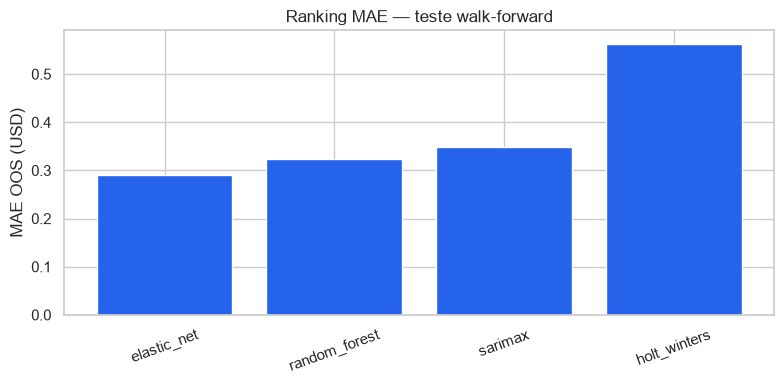

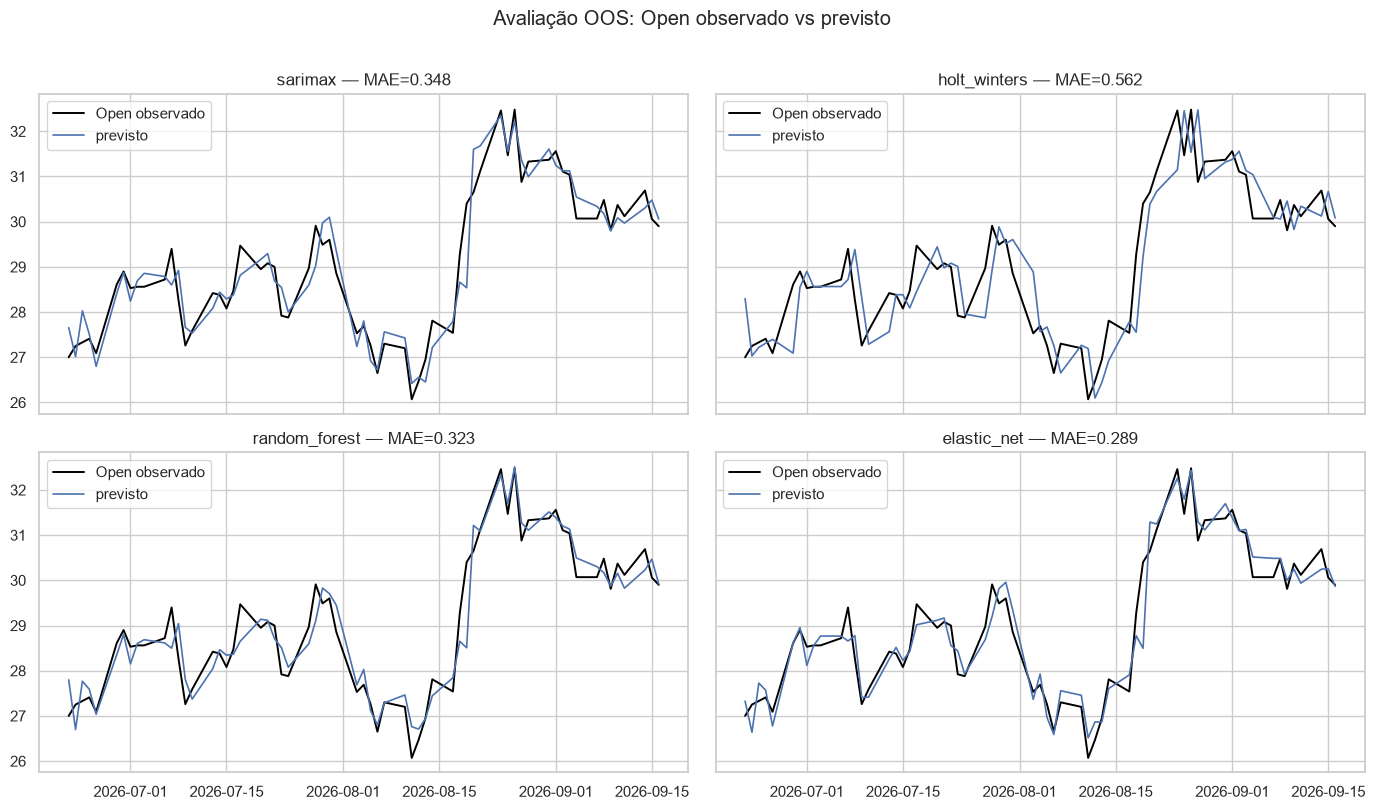

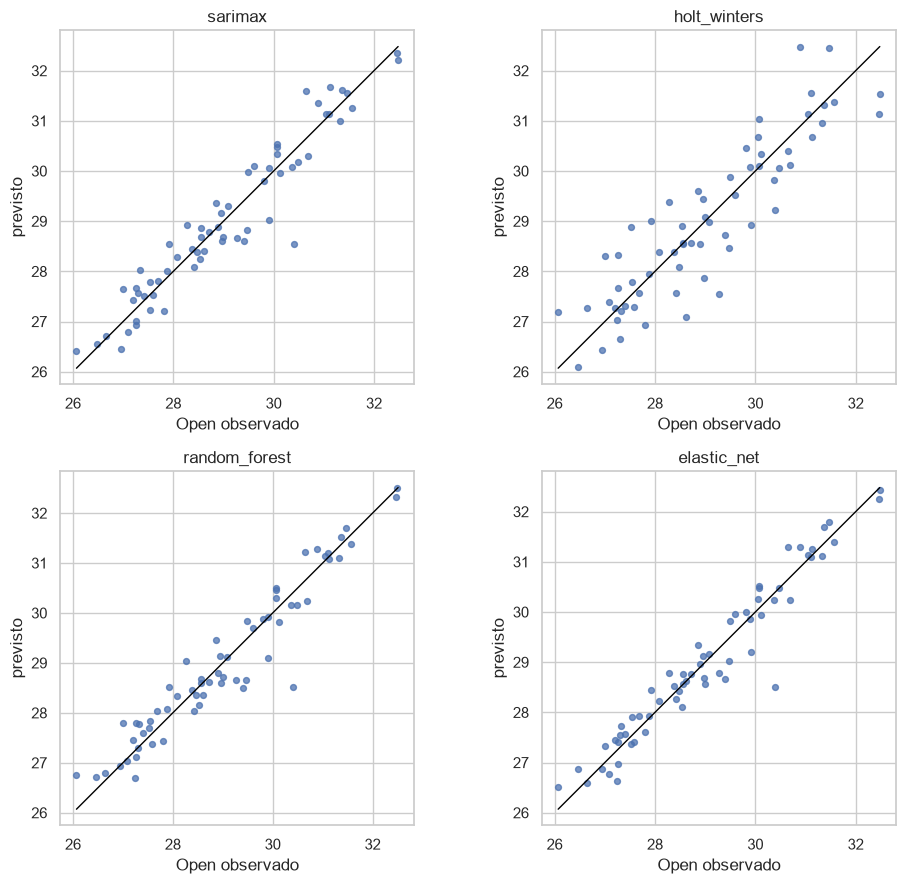

In [7]:
mae_rows = []
for model_name, pred_df in predictions.items():
    score = float(np.mean(np.abs(pred_df["y_true"] - pred_df["y_pred"])))
    mae_rows.append({
        "base_id": BASE_ID,
        "model": model_name,
        "mae": score,
        "n_predictions": len(pred_df),
    })
mae_table = pd.DataFrame(mae_rows).sort_values("mae").reset_index(drop=True)
mae_table["rank"] = np.arange(1, len(mae_table) + 1)
mae_table = mae_table[["base_id", "model", "mae", "rank", "n_predictions"]]
mae_table.to_csv(DATA_DIR / f"mae_{BASE_ID}.csv", index=False)
display(mae_table)
print("Vencedor nesta base:", mae_table.iloc[0]["model"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(mae_table["model"], mae_table["mae"], color="#2563eb")
ax.set(ylabel="MAE OOS (USD)", title="Ranking MAE — teste walk-forward")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
axes = axes.ravel()
for ax, model_name in zip(axes, model_names):
    pred_df = predictions[model_name]
    ax.plot(pred_df["forecast_date"], pred_df["y_true"], label="Open observado", color="black", linewidth=1.4)
    ax.plot(pred_df["forecast_date"], pred_df["y_pred"], label="previsto", linewidth=1.2)
    ax.set_title(f"{model_name} — MAE={mae_table.loc[mae_table.model==model_name, 'mae'].iloc[0]:.3f}")
    ax.legend(loc="upper left")
fig.suptitle("Avaliação OOS: Open observado vs previsto", y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.ravel()
for ax, model_name in zip(axes, model_names):
    pred_df = predictions[model_name]
    ax.scatter(pred_df["y_true"], pred_df["y_pred"], s=18, alpha=0.75)
    lo = min(pred_df["y_true"].min(), pred_df["y_pred"].min())
    hi = max(pred_df["y_true"].max(), pred_df["y_pred"].max())
    ax.plot([lo, hi], [lo, hi], color="black", linewidth=1)
    ax.set(xlabel="Open observado", ylabel="previsto", title=model_name, aspect="equal")
plt.tight_layout()
plt.show()


O ranking exibido acima é o resultado efetivo da execução. Em séries acionárias, modelos persistentes costumam ser fortes em `h=1`; a comparação walk-forward mostra se as exógenas e a regularização acrescentam valor fora da amostra.


## H. Resíduos OOS, ACF, PACF e Ljung–Box

Os resíduos são `observado − previsto`. Como `h=1` e cada origem avança um pregão, formam uma sequência temporal sem horizontes sobrepostos. Ljung–Box é calculado nos lags 5 e 10.


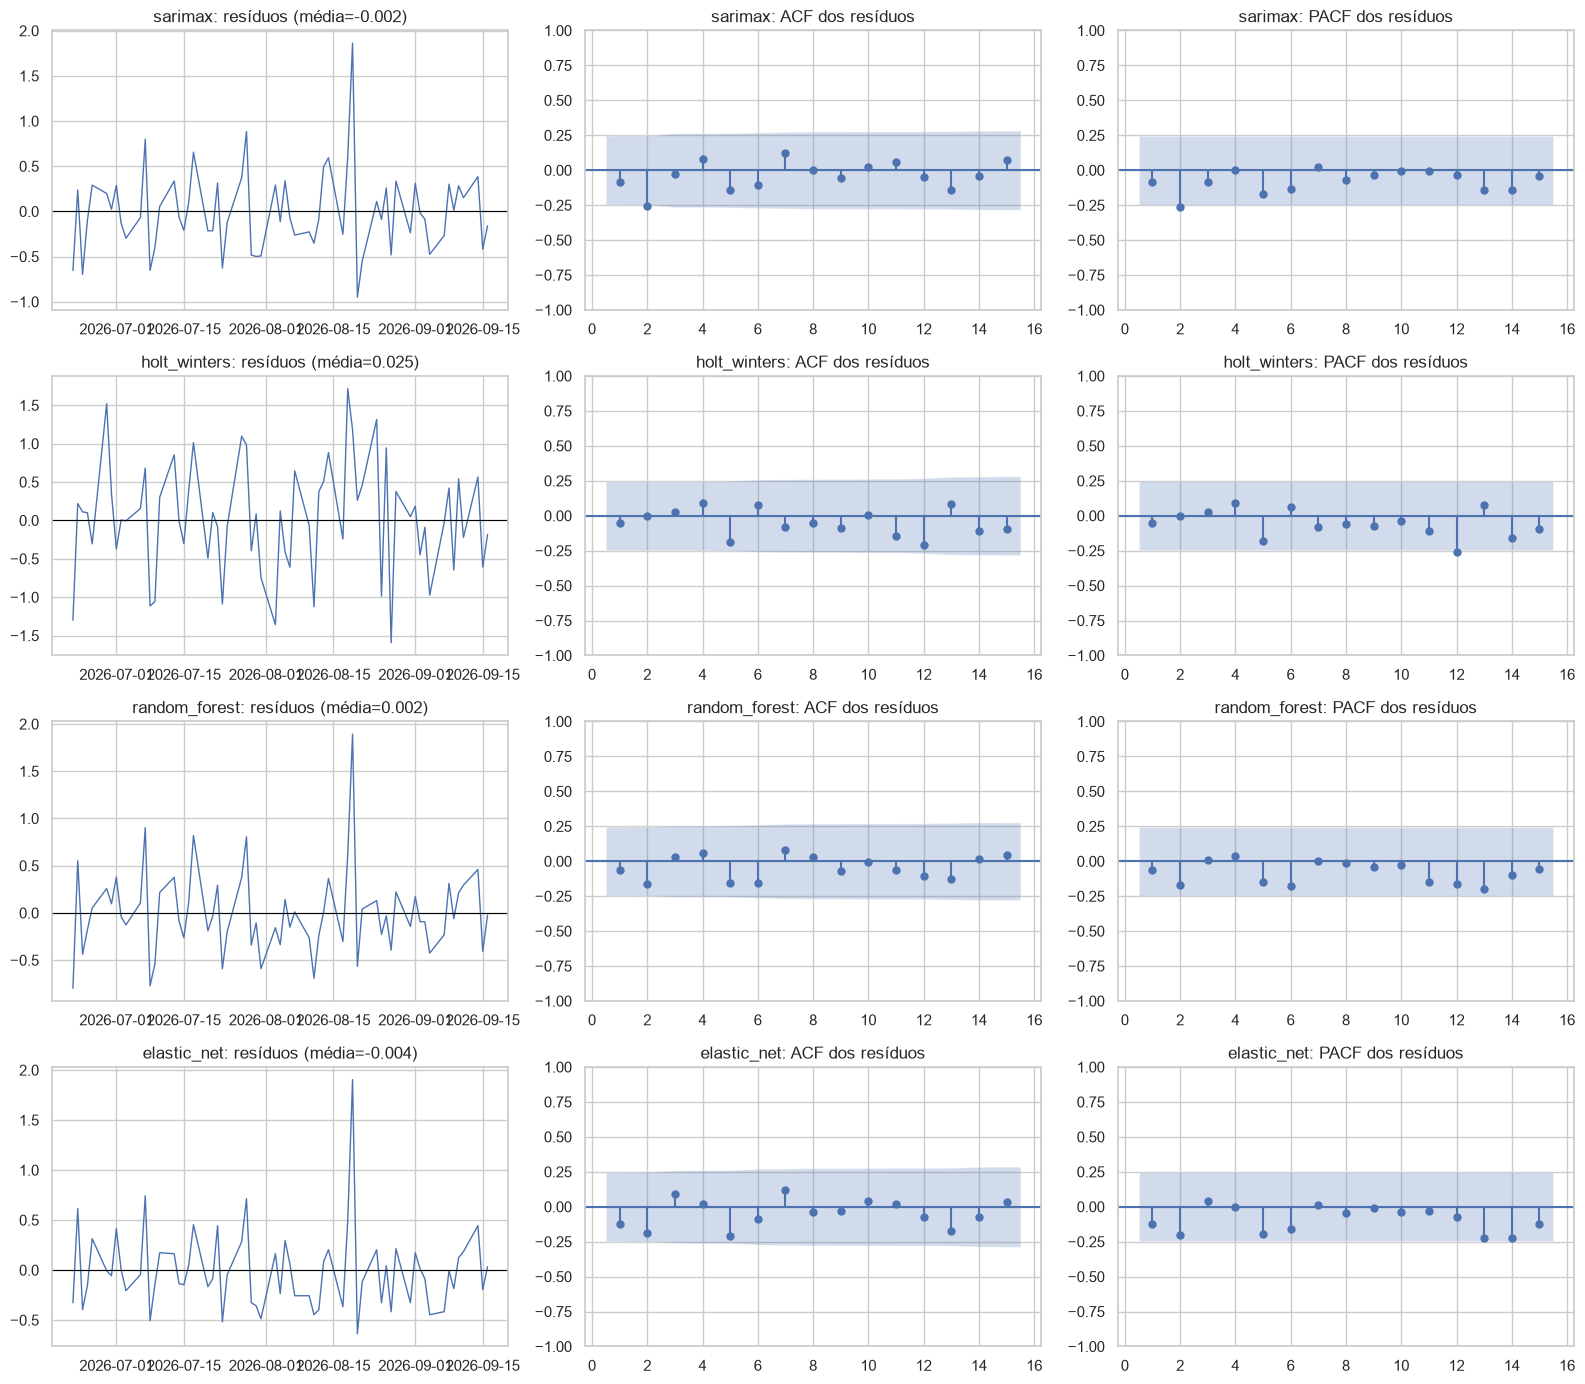

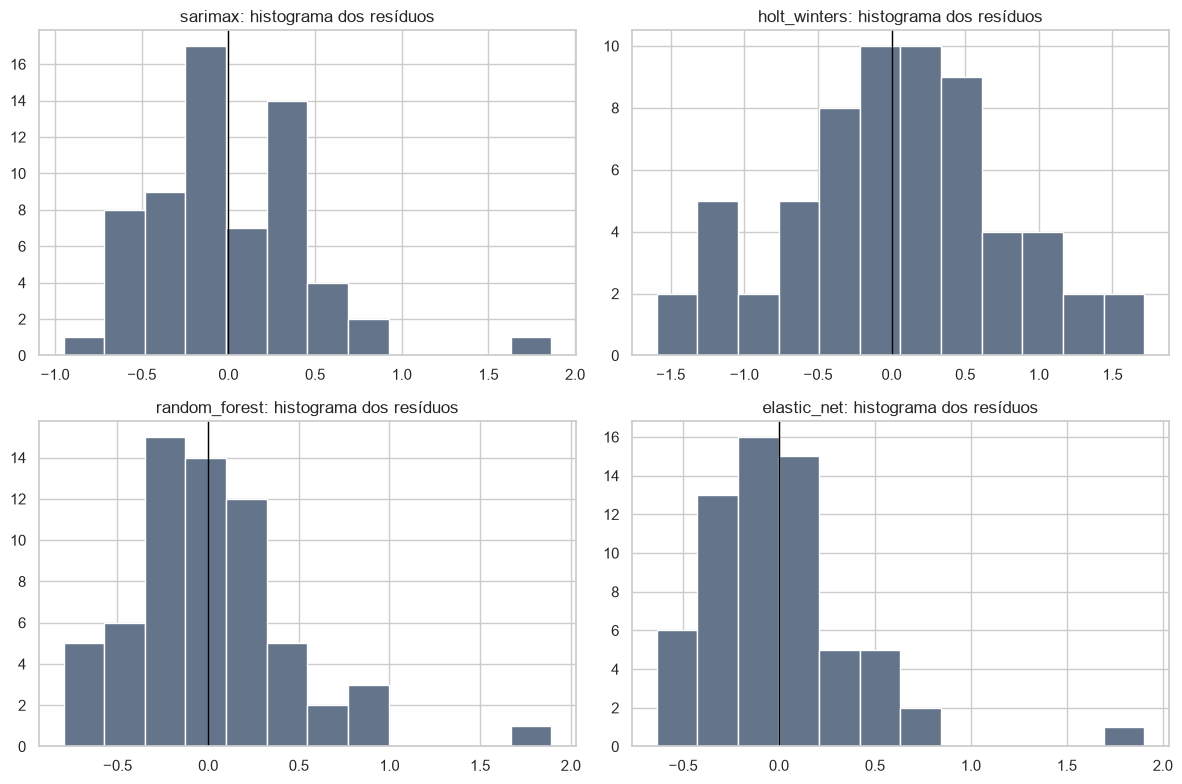

,base_id,model,horizon_step,lag,lb_stat,p_value,n_residuals
0,base_02,sarimax,1,5,6.725322,0.241883,63
1,base_02,sarimax,1,10,8.919822,0.539729,63
2,base_02,holt_winters,1,5,3.328385,0.649499,63
3,base_02,holt_winters,1,10,5.041369,0.888397,63
4,base_02,random_forest,1,5,4.143413,0.528958,63
5,base_02,random_forest,1,10,6.860211,0.738573,63
6,base_02,elastic_net,1,5,7.102356,0.213139,63
7,base_02,elastic_net,1,10,8.990669,0.532989,63


p < 0,05 indica evidência de autocorrelação residual no lag correspondente.


In [8]:
ljung_rows = []
fig, axes = plt.subplots(len(model_names), 3, figsize=(16, 14))
for row_idx, model_name in enumerate(model_names):
    pred_df = predictions[model_name].copy()
    pred_df["residual"] = pred_df["y_true"] - pred_df["y_pred"]
    residual_cols = key_cols + ["y_true", "y_pred", "residual"]
    pred_df[residual_cols].to_csv(DATA_DIR / f"residuals_{model_name}_{BASE_ID}.csv", index=False)
    residuals = pred_df["residual"]
    residual_lags = min(15, max(5, len(residuals) // 4))
    axes[row_idx, 0].plot(pred_df["forecast_date"], residuals, linewidth=1)
    axes[row_idx, 0].axhline(0, color="black", linewidth=0.8)
    axes[row_idx, 0].set_title(f"{model_name}: resíduos (média={residuals.mean():.3f})")
    plot_acf(residuals, lags=residual_lags, ax=axes[row_idx, 1], zero=False)
    axes[row_idx, 1].set_title(f"{model_name}: ACF dos resíduos")
    plot_pacf(residuals, lags=residual_lags, ax=axes[row_idx, 2], zero=False, method="ywm")
    axes[row_idx, 2].set_title(f"{model_name}: PACF dos resíduos")
    for lag in [5, 10]:
        lb = acorr_ljungbox(residuals, lags=[lag], return_df=True).iloc[0]
        ljung_rows.append({
            "base_id": BASE_ID,
            "model": model_name,
            "horizon_step": 1,
            "lag": lag,
            "lb_stat": float(lb["lb_stat"]),
            "p_value": float(lb["lb_pvalue"]),
            "n_residuals": len(residuals),
        })
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for ax, model_name in zip(axes, model_names):
    residuals = predictions[model_name]["y_true"] - predictions[model_name]["y_pred"]
    ax.hist(residuals, bins=12, color="#64748b", edgecolor="white")
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"{model_name}: histograma dos resíduos")
plt.tight_layout()
plt.show()

ljung_table = pd.DataFrame(ljung_rows)
ljung_table.to_csv(DATA_DIR / f"ljung_box_{BASE_ID}.csv", index=False)
display(ljung_table)
print("p < 0,05 indica evidência de autocorrelação residual no lag correspondente.")


As tabelas acima permitem avaliar viés e autocorrelação residual. `p < 0,05` no Ljung–Box indica estrutura temporal remanescente no lag correspondente; isso deve ser interpretado junto ao MAE, não isoladamente.


## I. Importância e persistência dos modelos finais

Após congelar as previsões OOS, os modelos finais são reajustados com todas as amostras. O Elastic Net final mantém o alvo interno em gap contra `close_lag_1`, e a reconstrução do preço é aplicada na previsão. A importância por permutação é calculada com o Random Forest treinado apenas no desenvolvimento e avaliado no teste, preservando a interpretação fora da amostra.


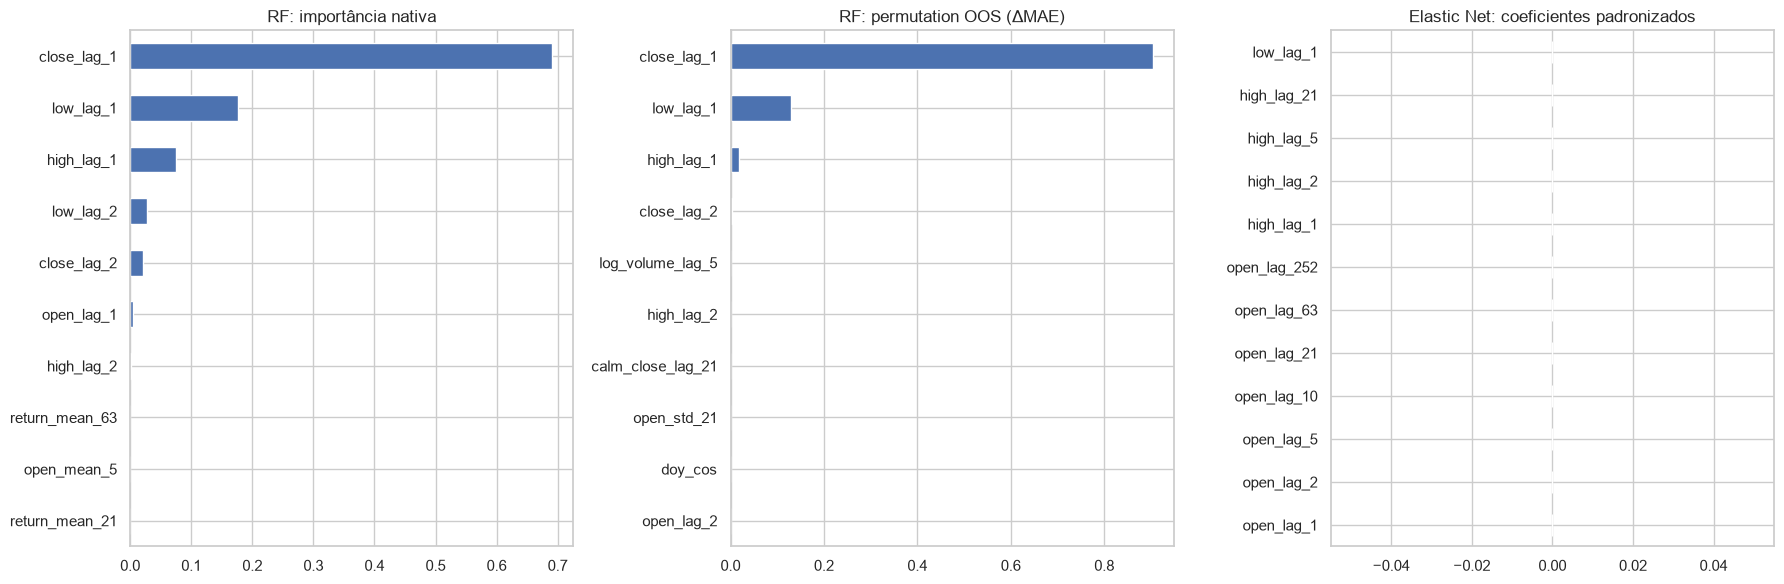

,rf_native,rf_permutation_oos
close_lag_1,0.691032,0.903426
low_lag_1,0.177015,0.129261
high_lag_1,0.075253,0.018245
close_lag_2,0.021708,0.003140
log_volume_lag_5,0.000014,0.001883
high_lag_2,0.000911,0.001106
calm_close_lag_21,0.000018,0.001014
open_std_21,0.000022,0.000691
doy_cos,0.000015,0.000691
open_lag_2,0.000025,0.000639


,elastic_net_standardized_coefficient
open_lag_1,0.0
open_lag_2,0.0
open_lag_5,0.0
open_lag_10,0.0
open_lag_21,0.0
open_lag_63,0.0
open_lag_252,0.0
high_lag_1,0.0
high_lag_2,0.0
high_lag_5,0.0


Coeficientes Elastic Net zerados: 59 de 59


,coefficient,p_value
close_lag_1,0.879957,0.000000
log_volume_lag_1,-0.000780,0.698647
tsn_close_lag_1,0.012829,0.006064
xlp_close_lag_1,-0.034392,0.000005
calm_close_lag_1,0.007252,0.121317
usd_mxn_lag_1,0.051272,0.045270
dow_sin,0.008618,0.088598
dow_cos,0.002831,0.596666


Holt-Winters: interpretação estrutural por nível/tendência/sazonalidade; não há FI tabular.


In [9]:
full_x = samples[feature_cols]
full_y = samples["target"]

final_rf = clone(rf_base).set_params(**rf_params, n_jobs=-1).fit(full_x, full_y)
final_en = clone(en_base).set_params(**en_params).fit(full_x, samples["target_gap_close"])
final_sarimax = SARIMAX(
    full_y,
    exog=samples[sarimax_features],
    order=tuple(sarimax_params["order"]),
    seasonal_order=tuple(sarimax_params["seasonal_order"]),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=40)
final_hw = ExponentialSmoothing(
    full_y.to_numpy(),
    trend=hw_params["trend"],
    damped_trend=hw_params["damped_trend"],
    seasonal=hw_params["seasonal"],
    seasonal_periods=hw_params.get("seasonal_periods"),
    initialization_method="estimated",
).fit(optimized=True)

joblib.dump(final_rf, ARTIFACT_DIR / "random_forest.pkl")
joblib.dump(final_en, ARTIFACT_DIR / "elastic_net.pkl")
with open(ARTIFACT_DIR / "sarimax.pkl", "wb") as f:
    pickle.dump(final_sarimax, f)
with open(ARTIFACT_DIR / "holt_winters.pkl", "wb") as f:
    pickle.dump(final_hw, f)

version_info = {
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn.__version__,
    "statsmodels": statsmodels.__version__,
}
selected_params = {
    "sarimax": sarimax_params,
    "holt_winters": hw_params,
    "random_forest": rf_params,
    "elastic_net": en_params,
}
for model_name in model_names:
    meta = {
        "base_id": BASE_ID,
        "model": model_name,
        "hyperparams": selected_params[model_name],
        "training_end": str(cleaned["Date"].max().date()),
        "trained_at": datetime.now(timezone.utc).isoformat(),
        "random_state": RANDOM_STATE,
        "horizon": HORIZON,
        "multi_step_strategy": "direct_one_step",
        "versions": version_info,
    }
    with open(ARTIFACT_DIR / f"{model_name}_meta.json", "w") as f:
        json.dump(meta, f, indent=2)

rf_importance = pd.Series(final_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
en_coef = pd.Series(final_en.named_steps["model"].coef_, index=feature_cols).sort_values(key=np.abs, ascending=False)
perm = permutation_importance(
    rf_gs.best_estimator_,
    test_samples[feature_cols],
    test_samples["target"],
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
perm_importance = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
rf_importance.head(10).sort_values().plot.barh(ax=axes[0], title="RF: importância nativa")
perm_importance.head(10).sort_values().plot.barh(ax=axes[1], title="RF: permutation OOS (ΔMAE)")
en_coef.head(12).sort_values().plot.barh(ax=axes[2], title="Elastic Net: coeficientes padronizados")
plt.tight_layout()
plt.show()
display(pd.DataFrame({"rf_native": rf_importance, "rf_permutation_oos": perm_importance}).sort_values("rf_permutation_oos", ascending=False).head(12))
display(en_coef.rename("elastic_net_standardized_coefficient").to_frame().head(12))
print("Coeficientes Elastic Net zerados:", int((en_coef == 0).sum()), "de", len(en_coef))

sarimax_interpretation = pd.DataFrame({
    "coefficient": final_sarimax.params,
    "p_value": final_sarimax.pvalues,
})
display(sarimax_interpretation.loc[sarimax_interpretation.index.intersection(sarimax_features)])
print("Holt-Winters: interpretação estrutural por nível/tendência/sazonalidade; não há FI tabular.")


importance_table = pd.DataFrame({
    "feature": feature_cols,
    "rf_native": [float(rf_importance.get(c, np.nan)) for c in feature_cols],
    "rf_permutation_oos": [float(perm_importance.get(c, np.nan)) for c in feature_cols],
    "elastic_net_coefficient": [float(en_coef.get(c, np.nan)) for c in feature_cols],
})
importance_table.to_csv(DATA_DIR / f"feature_importance_{BASE_ID}.csv", index=False)


### Elastic Net — estudo local

Elastic Net combina penalizações L1 e L2. Nesta versão, ele aprende o gap `Open - close_lag_1`, que é mais estacionário que o preço em nível. O scaler está dentro do pipeline, e os coeficientes mostrados estão na escala padronizada. Coeficientes zerados indicam seleção de variáveis; a relevância deve ser comparada à importância OOS do Random Forest e ao MAE final.


In [10]:
# Validação final de artefatos e contratos.
required_data = [
    DATA_DIR / f"cleaned_{BASE_ID}.csv",
    DATA_DIR / f"features_{BASE_ID}.parquet",
    DATA_DIR / f"feature_importance_{BASE_ID}.csv",
    DATA_DIR / f"mae_{BASE_ID}.csv",
    DATA_DIR / f"ljung_box_{BASE_ID}.csv",
]
for model_name in model_names:
    required_data.extend([
        DATA_DIR / f"predictions_{model_name}_{BASE_ID}.csv",
        DATA_DIR / f"residuals_{model_name}_{BASE_ID}.csv",
        DATA_DIR / f"hyperparams_{model_name}_{BASE_ID}.json",
    ])
    assert (ARTIFACT_DIR / f"{model_name}.pkl").exists()
    assert (ARTIFACT_DIR / f"{model_name}_meta.json").exists()
assert all(path.exists() and path.stat().st_size > 0 for path in required_data)
assert hashlib.sha256(RAW_FILE.read_bytes()).hexdigest() == raw_hash_before
assert len(mae_table) == 4
assert mae_table["n_predictions"].eq(TEST_OBS).all()
assert np.isfinite(mae_table["mae"]).all()
for model_name in model_names:
    assert np.isfinite(predictions[model_name][["y_true", "y_pred"]].to_numpy()).all()
print(f"VALIDAÇÃO FINAL OK: {len(required_data)} arquivos de dados e 8 artefatos de modelo.")
print("Raw preservado por SHA-256; notebook concluiu sem estado oculto.")


VALIDAÇÃO FINAL OK: 17 arquivos de dados e 8 artefatos de modelo.
Raw preservado por SHA-256; notebook concluiu sem estado oculto.
